**Employee Attrition Prediction & Workforce Analytics**

Built a machine learning model to predict employee attrition and identify key factors associated with employees leaving.
Compared multiple classification models and optimized the prediction threshold to improve identification of potential attrition cases.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [9]:
df["Attrition"].value_counts(normalize=True) * 100


,proportion
Attrition,
No,83.877551
Yes,16.122449


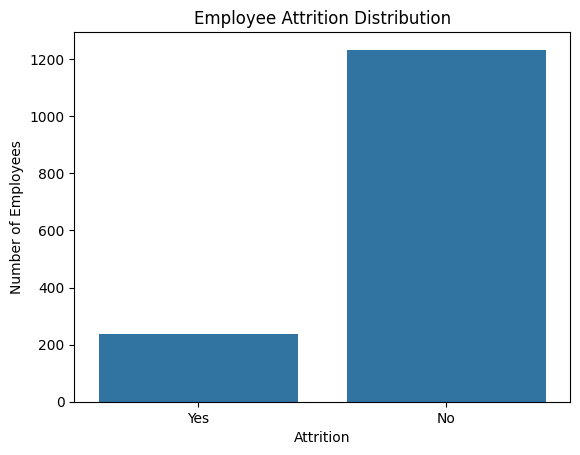

In [10]:
sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [11]:
df.nunique().sort_values()

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [12]:
df = df.drop(columns=[
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
])

In [14]:
df.shape

(1470, 31)

In [15]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [16]:
df.describe(include="object")


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,No
freq,1233,1043,961,606,882,326,673,1054


In [19]:
pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


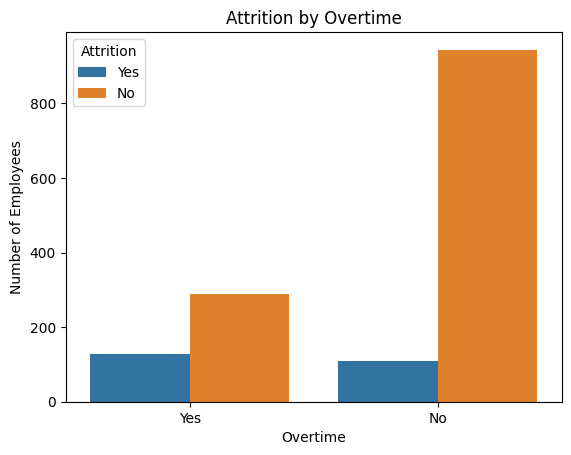

In [18]:
sns.countplot(x="OverTime", hue="Attrition", data=df)

plt.title("Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.show()

In [20]:
df.groupby("Attrition")["Age"].mean()


,Age
Attrition,
No,37.561233
Yes,33.607595


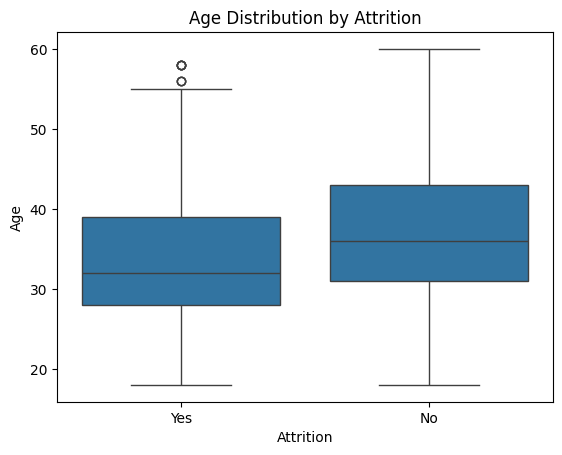

In [21]:
sns.boxplot(x="Attrition", y="Age", data=df)

plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

In [22]:
df.groupby("Attrition")["MonthlyIncome"].mean()

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


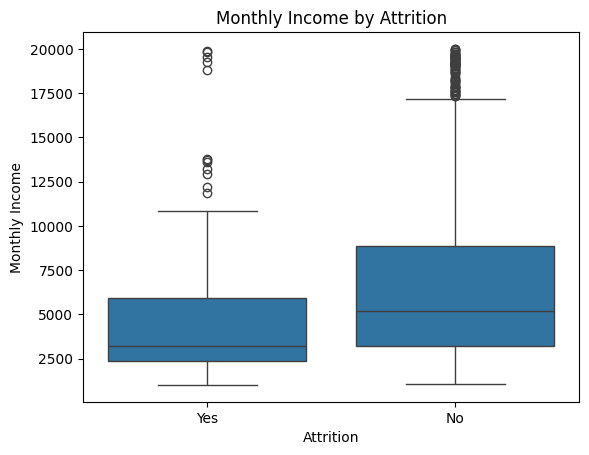

In [23]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

In [24]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


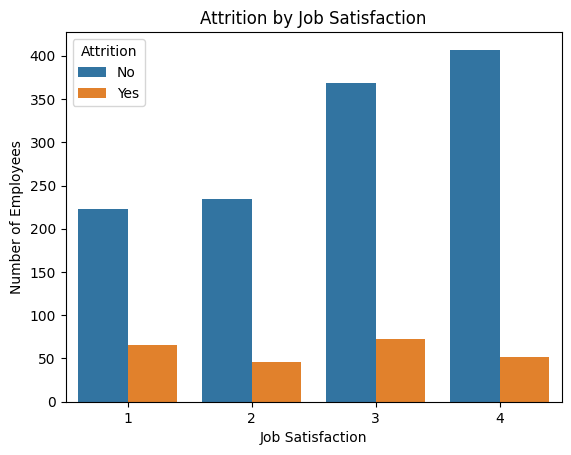

In [25]:
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)

plt.title("Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.show()

In [26]:
df.groupby("Attrition")["YearsAtCompany"].mean()

,YearsAtCompany
Attrition,
No,7.369019
Yes,5.130802


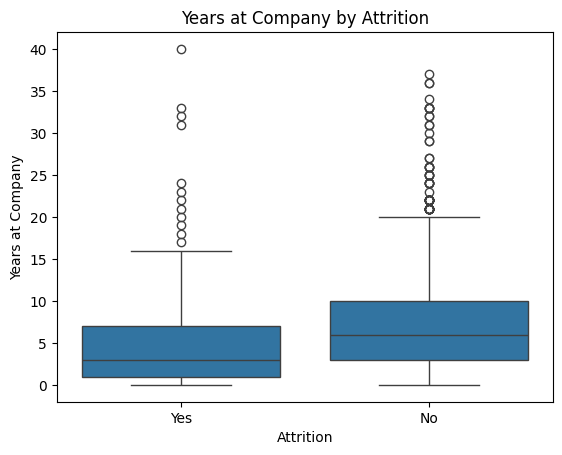

In [27]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)

plt.title("Years at Company by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.show()

In [28]:
pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


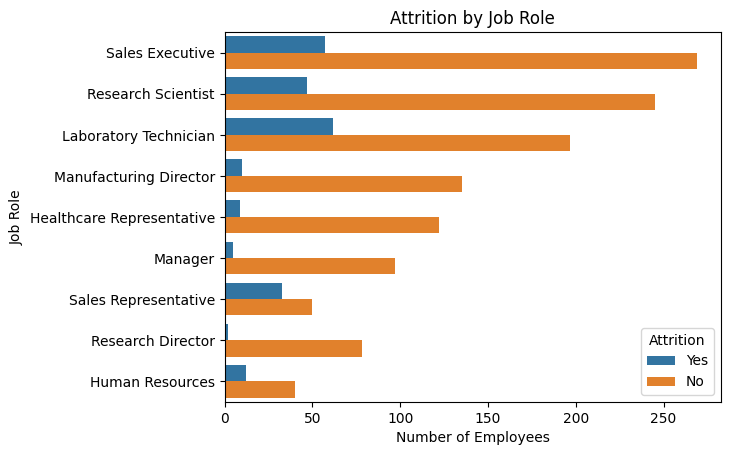

In [29]:
sns.countplot(
    y="JobRole",
    hue="Attrition",
    data=df
)

plt.title("Attrition by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.show()

In [30]:
pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


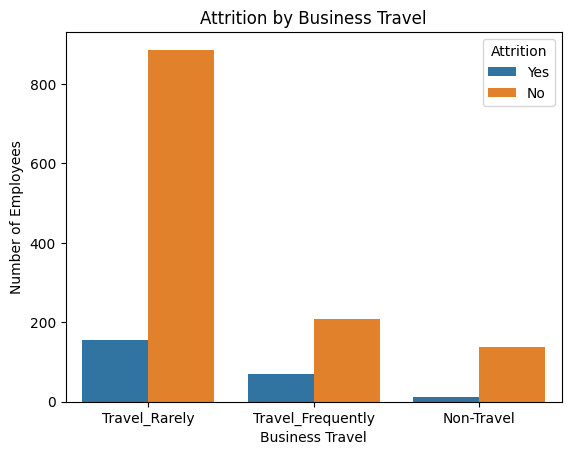

In [31]:
sns.countplot(
    x="BusinessTravel",
    hue="Attrition",
    data=df
)

plt.title("Attrition by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Number of Employees")
plt.show()

In [32]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [33]:
correlation = df.corr(numeric_only=True)["Attrition"].sort_values(ascending=False)

correlation

,Attrition
Attrition,1.000000
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
PerformanceRating,0.002889
HourlyRate,-0.006846
PercentSalaryHike,-0.013478
Education,-0.031373
YearsSinceLastPromotion,-0.033019
RelationshipSatisfaction,-0.045872


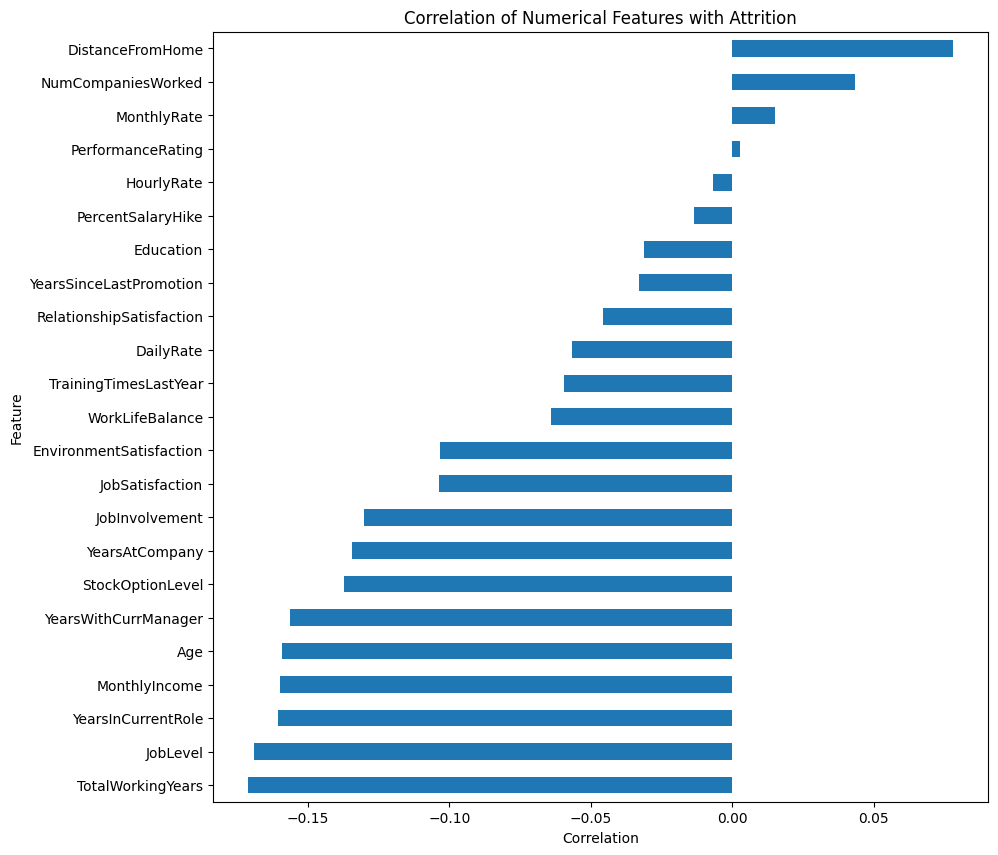

In [34]:
correlation.drop("Attrition").sort_values().plot(kind="barh", figsize=(10, 10))

plt.title("Correlation of Numerical Features with Attrition")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

In [35]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [36]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 30)
y shape: (1470,)


In [37]:
categorical_cols = X.select_dtypes(include="object").columns

categorical_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1176, 30)
X_test: (294, 30)
y_train: (1176,)
y_test: (294,)


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [41]:
numerical_cols = X.select_dtypes(exclude="object").columns

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [43]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [44]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

In [45]:
y_pred_log = log_model.predict(X_test_processed)
y_prob_log = log_model.predict_proba(X_test_processed)[:, 1]


In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8605442176870748
ROC-AUC: 0.8115255405289

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



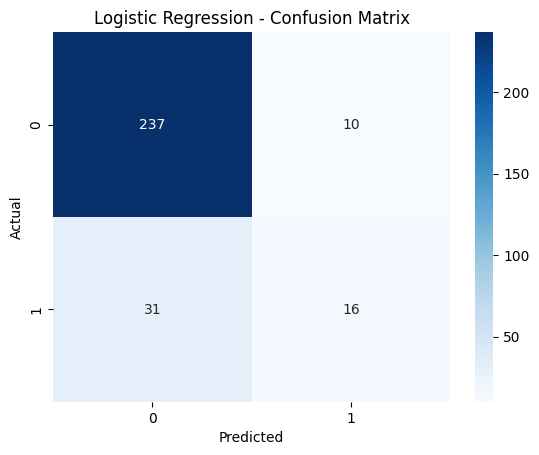

In [47]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
from sklearn.tree import DecisionTreeClassifier

In [49]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [50]:
y_pred_dt = dt_model.predict(X_test_processed)
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Accuracy: 0.8367346938775511
ROC-AUC: 0.6618141097424413

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.47      0.19      0.27        47

    accuracy                           0.84       294
   macro avg       0.67      0.58      0.59       294
weighted avg       0.80      0.84      0.81       294



In [52]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [53]:
y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8469387755102041
ROC-AUC: 0.7903350848479628

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294



In [55]:
!pip install xgboost -q
from xgboost import XGBClassifier

In [56]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8707482993197279
ROC-AUC: 0.788353863381859

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.74      0.30      0.42        47

    accuracy                           0.87       294
   macro avg       0.81      0.64      0.68       294
weighted avg       0.86      0.87      0.85       294



In [59]:
from sklearn.model_selection import GridSearchCV

In [60]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

In [61]:
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='roc_auc')

In [62]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best Parameters: {'C': 100, 'solver': 'liblinear'}
Best CV ROC-AUC: 0.8357801903620766


In [63]:
best_log_model = grid_search.best_estimator_

y_pred_tuned = best_log_model.predict(X_test_processed)
y_prob_tuned = best_log_model.predict_proba(X_test_processed)[:, 1]

In [64]:
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Accuracy: 0.8571428571428571
ROC-AUC: 0.8071323972779739

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.59      0.34      0.43        47

    accuracy                           0.86       294
   macro avg       0.74      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



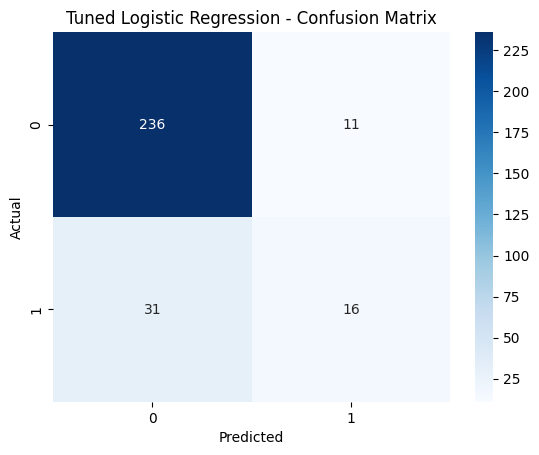

In [65]:
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [66]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]
for threshold in thresholds:
    y_pred_threshold = (y_prob_tuned >= threshold).astype(int)
    print(f"Threshold: {threshold}")
    print(f"Precision: {precision_score(y_test, y_pred_threshold):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred_threshold):.2f}")
    print(f"F1 Score: {f1_score(y_test, y_pred_threshold):.2f}")
    print()

Threshold: 0.3
Precision: 0.50
Recall: 0.51
F1 Score: 0.51

Threshold: 0.35
Precision: 0.49
Recall: 0.45
F1 Score: 0.47

Threshold: 0.4
Precision: 0.55
Recall: 0.45
F1 Score: 0.49

Threshold: 0.45
Precision: 0.61
Recall: 0.40
F1 Score: 0.49

Threshold: 0.5
Precision: 0.59
Recall: 0.34
F1 Score: 0.43



In [67]:
final_threshold = 0.30
y_pred_final = (y_prob_tuned >= final_threshold).astype(int)
print("Final Threshold:", final_threshold)
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

Final Threshold: 0.3
Precision: 0.5
Recall: 0.5106382978723404
F1 Score: 0.5052631578947369


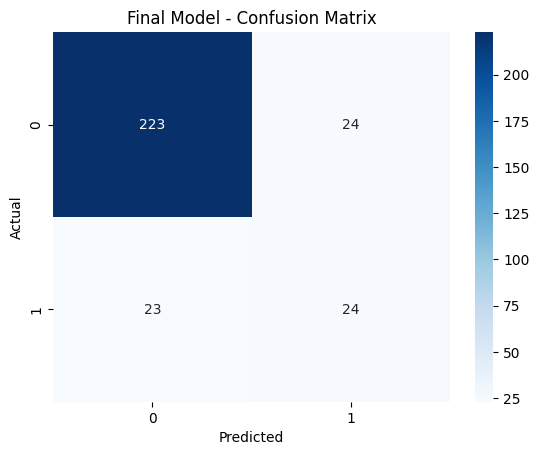

In [68]:
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Final Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
feature_names = preprocessor.get_feature_names_out()

coefficients = best_log_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoefficient": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "AbsCoefficient",
    ascending=False
)
feature_importance.head(15)

,Feature,Coefficient,AbsCoefficient
42,cat__JobRole_Research Director,-2.839940,2.839940
38,cat__JobRole_Human Resources,2.553387,2.553387
26,cat__Department_Human Resources,-1.871782,1.871782
45,cat__JobRole_Sales Representative,1.476771,1.476771
49,cat__OverTime_No,-1.440317,1.440317
23,cat__BusinessTravel_Non-Travel,-1.359963,1.359963
37,cat__JobRole_Healthcare Representative,-1.200065,1.200065
33,cat__EducationField_Other,-1.144638,1.144638
29,cat__EducationField_Human Resources,0.898732,0.898732
41,cat__JobRole_Manufacturing Director,-0.884728,0.884728


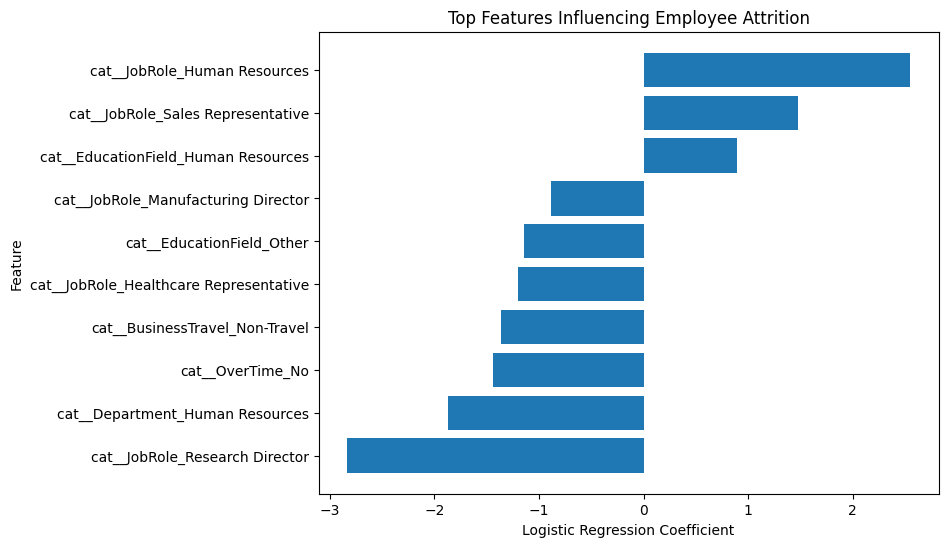

In [72]:
top_features = feature_importance.head(10).sort_values("Coefficient")

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Features Influencing Employee Attrition")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

In [73]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.8605,
        0.8367,
        0.8469,
        0.8707
    ],
    "ROC-AUC": [
        0.8115,
        0.6618,
        0.7903,
        0.7884
    ],
    "Attrition Recall": [
        0.34,
        0.19,
        0.11,
        0.30
    ],
    "Attrition F1": [
        0.44,
        0.27,
        0.18,
        0.42
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC,Attrition Recall,Attrition F1
0,Logistic Regression,0.8605,0.8115,0.34,0.44
1,Decision Tree,0.8367,0.6618,0.19,0.27
2,Random Forest,0.8469,0.7903,0.11,0.18
3,XGBoost,0.8707,0.7884,0.30,0.42


### Business Insights

* Employees working overtime showed a higher attrition rate than employees who did not work overtime.
* Employees who left had a lower average monthly income than employees who stayed.
* Employees who left were younger on average than employees who stayed.
* Employees who left generally had fewer years at the company, indicating a relationship between shorter tenure and attrition.
* Attrition patterns varied across different job roles and business travel categories.
* The final Logistic Regression model achieved an ROC-AUC of **0.807**.
* Lowering the classification threshold from 0.50 to **0.30** increased attrition recall from **34% to 51%**, helping the model identify more potential attrition cases.
* These findings represent associations in the dataset and should not be interpreted as proof of causation.


### Conclusion

This project developed an end-to-end machine learning solution for predicting employee attrition. The analysis included data cleaning, exploratory data analysis, feature preprocessing, model comparison, hyperparameter tuning, threshold optimization, and model interpretation.

Logistic Regression provided a strong balance between predictive performance and interpretability. The classification threshold was adjusted to 0.30 to improve the model's ability to identify employees who may leave.

The project demonstrates how machine learning can be combined with employee-level data analysis to identify patterns associated with workforce attrition and support data-driven HR decision-making.


## Project Summary

**Employee Attrition Prediction & Workforce Analytics**

* Analyzed employee data to identify patterns associated with workforce attrition.
* Performed data cleaning, exploratory data analysis, feature preprocessing, and feature engineering.
* Compared Logistic Regression, Decision Tree, Random Forest, and XGBoost classification models.
* Used cross-validation and hyperparameter tuning to improve model selection.
* Optimized the classification threshold from 0.50 to 0.30, increasing attrition recall from 34% to 51%.
* Used Logistic Regression coefficients to interpret features influencing model predictions.
* Translated model findings into business insights that could support employee retention strategies.
